In [1]:
import numpy as np
import math
from scipy.constants import m_e, c, e, physical_constants
from scipy.special import gamma
import matplotlib.pyplot as plt

In [2]:
a0 = 0.05
tau = 100e-15
lambd = 0.8e-6
dt = lambd/c/80

omega = 2*np.pi*c/lambd
E0 = m_e*omega*c/e

In [3]:
inv_tau2 = 1./tau**2

def a_env(t):
    return a0*math.exp(-inv_tau2*t**2)

@np.vectorize
def a(t):
    return a_env(t)*math.cos(omega*t)

@np.vectorize
def E(t):
    return E0*a_env(t)*math.sin(omega*t)

In [4]:
Uion = 13.6*e  # ionization energy in Joules, for Hydrogen

# Calculate the ADK prefactors (See Chen, JCP 236 (2013), equation (2))
# - Scalars
alpha = physical_constants['fine-structure constant'][0]
r_e = physical_constants['classical electron radius'][0]
wa = alpha**3 * c / r_e
Ea = m_e*c**2/e * alpha**4/r_e
# - Arrays (one element per ionization level)
UH = 13.6*e
Z = 1
n_eff = Z * np.sqrt( UH/Uion )
l_eff = n_eff - 1
C2 = 2**(2*n_eff) / (n_eff * gamma(n_eff+l_eff+1) * gamma(n_eff-l_eff))
# For now, we assume l=0, m=0
adk_power = - (2*n_eff - 1)
adk_prefactor = dt * wa * C2 * ( Uion/(2*UH) ) \
    * ( 2*(Uion/UH)**(3./2)*Ea )**(2*n_eff - 1)
adk_exp_prefactor = -2./3 * ( Uion/UH )**(3./2) * Ea

In [5]:
@np.vectorize
def get_ionization_probability( E ):
    """
    For one given macroparticle, calculate the ADK probability that the
    particle is ionized during this timestep.

    (The proper time of the particle is used, so that the ADK probability
    is fully Lorentz invariant and thus also works in a boosted frame.)
    """
    # Avoid singular expression for E = 0
    if E == 0:
        return(0)
    w_dtau = adk_prefactor * E**adk_power * math.exp( adk_exp_prefactor/E )
    p = 1. - math.exp( - w_dtau )
    return( p )

In [6]:
t_arr = -3*tau + dt*np.arange(int(3*tau/dt))

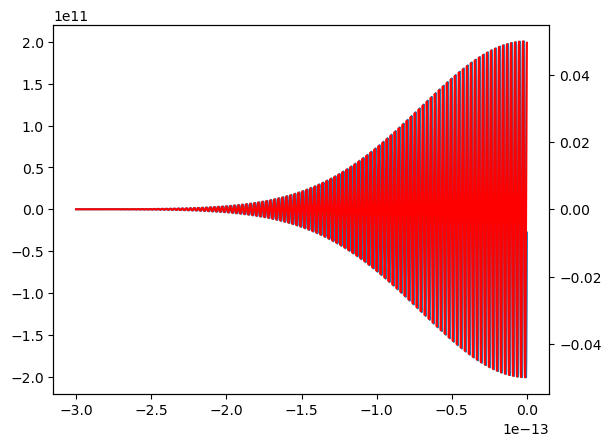

In [7]:
E_arr = E(t_arr)
a_arr = a(t_arr)
plt.plot( t_arr, E_arr )
plt.twinx()
plt.plot( t_arr, a_arr, color='r' )

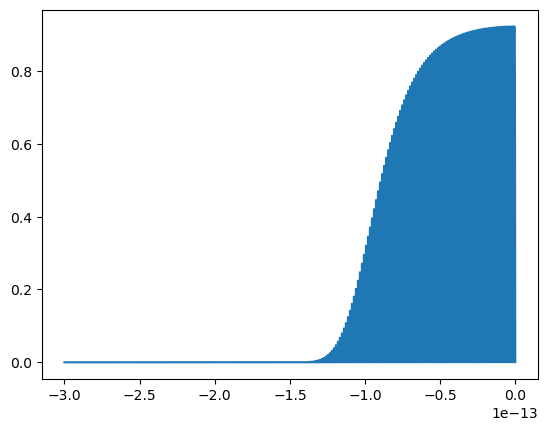

In [8]:
dp = get_ionization_probability( abs(E_arr) )
plt.plot( t_arr, dp )

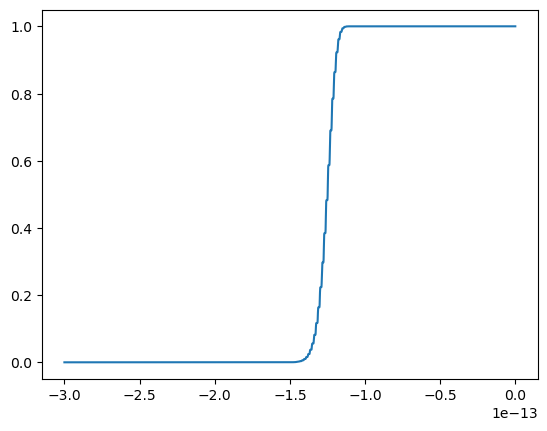

In [9]:
ioniz_frac = np.zeros_like(dp)
for i in range(len(ioniz_frac)-1):
    ioniz_frac[i+1] = ioniz_frac[i] + (1-ioniz_frac[i])*dp[i]
plt.plot( t_arr, ioniz_frac )

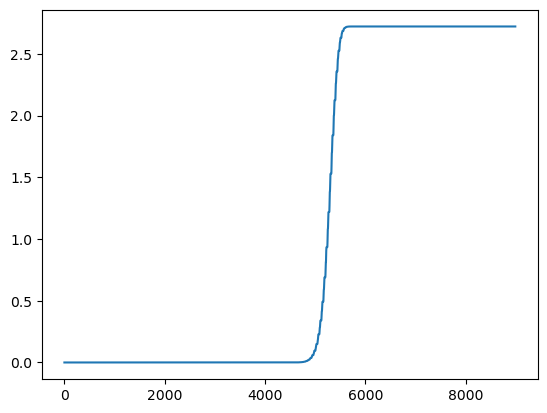

In [10]:
kin_energy = np.zeros_like(dp)
for i in range(len(ioniz_frac)-1):
    kin_energy[i+1] = kin_energy[i] + (1-ioniz_frac[i])*dp[i] * m_e*c**2/e * (math.sqrt( 1 + a_arr[i]**2 ) - 1) # in eV

plt.plot( kin_energy )

In [11]:
T = kin_energy/(3/2*ioniz_frac)

/tmp/ipykernel_3370743/2768235140.py:1: RuntimeWarning: invalid value encountered in divide
  T = kin_energy/(3/2*ioniz_frac)


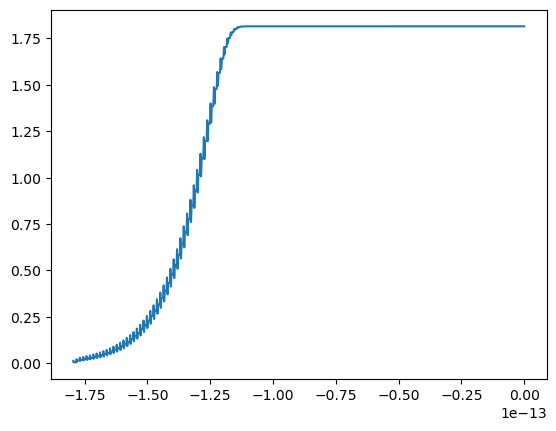

In [12]:
plt.plot(t_arr, T)